# 04 - Model Training and Prediction

**Objective:** Train classification models on Wine data and evaluate performance.

**Steps:**
1. Load engineered data and split into train/test
2. Scale features (for distance-based models)
3. Train multiple classification models
4. Evaluate and compare models
5. Log experiments with MLflow
6. Save models for later use

In [137]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Libraries imported successfully")

Libraries imported successfully


## Data Loading

In [138]:
# TODO: Load the engineered data from data/processed/engineered_data.csv
# If it doesn't exist, load clean_data.csv instead.
# Wine has 13 numerical features (chemical measurements) and a 3-class target.
# Target column is 'class' (0=cultivar_1, 1=cultivar_2, 2=cultivar_3).

PROCESSED_DIR = Path("../data/processed")

# TODO: Try to load engineered data, fallback to clean data
# Hint: Check if engineered_data.csv exists using Path.exists()

# TODO: Separate features and target
# Drop 'class' to get X, keep it as y.

# df = pd.read_csv(PROCESSED_DIR / "engineered_data.csv")
# X = df.drop(columns=["class"])
# y = df["class"]
# print(f"Features: {X.shape}, Target: {y.shape}")
# print(y.value_counts())

In [139]:
# Load engineered data (fallback to clean_data if not available)
PROCESSED_DIR = Path("../data/processed")

engineered_path = PROCESSED_DIR / "engineered_data.csv"
clean_path = PROCESSED_DIR / "clean_data.csv"

if engineered_path.exists():
    df = pd.read_csv(engineered_path)
    print(f"Loaded engineered_data.csv")
else:
    df = pd.read_csv(clean_path)
    print(f"Loaded clean_data.csv (engineered not found)")

# Separate features and target
X = df.drop(columns=["class"])
y = df["class"]

print(f"Features: {X.shape}, Target: {y.shape}")
print(f"Feature columns: {X.columns.tolist()}")
print(f"\nClass distribution:")
print(y.value_counts().sort_index())

Loaded engineered_data.csv
Features: (178, 18), Target: (178,)
Feature columns: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280_od315', 'proline', 'phenol_ratio', 'alcohol_color_ratio', 'alcohol_proline_ratio', 'color_hue_product', 'flavanoid_proline']

Class distribution:
class
0    59
1    71
2    48
Name: count, dtype: int64


In [140]:
# TODO: Split data into train and test sets
# Use train_test_split() to generate X_train, X_test, y_train, y_test.
# Use stratify=y to preserve the class balance in both splits.
# Set test_size=0.2 and random_state=42 for reproducibility.
# Wine has 178 samples (59/71/48 per class), so test will have ~36 samples.
#
# print(f"Train: {X_train.shape}, Test: {X_test.shape}")
# print(f"Train class balance:\n{y_train.value_counts(normalize=True)}")

In [141]:
# Split into train/test (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nTrain class balance:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print(f"\nTest class balance:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

Train: (142, 18), Test: (36, 18)

Train class balance:
class
0    0.331
1    0.401
2    0.268
Name: proportion, dtype: float64

Test class balance:
class
0    0.333
1    0.389
2    0.278
Name: proportion, dtype: float64


## Feature Scaling

In [142]:
# TODO: Scale features for Logistic Regression, SVC
# Define a StandardScaler and fit on the training data only.
# Use fit_transform() on X_train and transform() on X_test to prevent data leakage.
#
# TODO: Verify scaling
# print(f"Mean after scaling: {X_train_scaled.mean(axis=0)[:5]}")
# print(f"Std after scaling: {X_train_scaled.std(axis=0)[:5]}")
# Check with np.allclose() that the mean is near 0 and std near 1.

In [143]:
from sklearn.preprocessing import StandardScaler

# Fit scaler on training data only (prevent data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verify scaling
print("=== Scaling Verification (train set) ===")
print(f"Means (first 5): {X_train_scaled.mean(axis=0)[:5].round(10)}")
print(f"Stds  (first 5): {X_train_scaled.std(axis=0)[:5].round(4)}")
print(f"\nAll means near zero: {np.allclose(X_train_scaled.mean(axis=0), 0, atol=1e-10)}")
print(f"All stds near one:   {np.allclose(X_train_scaled.std(axis=0), 1, atol=0.01)}")

=== Scaling Verification (train set) ===
Means (first 5): [ 0.  0. -0.  0.  0.]
Stds  (first 5): [1. 1. 1. 1. 1.]

All means near zero: True
All stds near one:   True


## Model Training

Scikit-learn provides a consistent API for training various models.

Every predictor in scikit-learn has a `fit()` method for training and a `predict()` method for making predictions.

Each model has its own strengths and weaknesses, so we will train multiple models to compare their performance.

In [144]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [145]:
# TODO: Train Logistic Regression model (multiclass)
# Define a LogisticRegression classifier with multi_class='multinomial'.
# Set max_iter=1000 to ensure convergence. Fit on the scaled training data.
# Check the coefficients (shape should be 3 classes x 13 features).
# 

In [146]:
# Logistic Regression (uses scaled features)
lr_model = LogisticRegression(max_iter=5000, random_state=42, solver="lbfgs")
lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained")
print(f"Coefficients shape: {lr_model.coef_.shape} (3 classes x {X_train.shape[1]} features)")
print(f"Training accuracy: {lr_model.score(X_train_scaled, y_train):.4f}")

Logistic Regression trained
Coefficients shape: (3, 18) (3 classes x 18 features)
Training accuracy: 1.0000


In [147]:
# TODO: Train Random Forest model
# Define a RandomForestClassifier.
# Specify the number of trees with n_estimators (e.g., n_estimators=100).
# Fit on the training data and check feature importances.

In [148]:
# Random Forest (does not need scaling)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Random Forest trained")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Training accuracy: {rf_model.score(X_train, y_train):.4f}")
print(f"\nTop 5 feature importances:")
feat_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns)
print(feat_imp.sort_values(ascending=False).head(5).round(4))

Random Forest trained
Number of trees: 100
Training accuracy: 1.0000

Top 5 feature importances:
flavanoid_proline      0.2031
color_intensity        0.1211
alcohol_color_ratio    0.1068
proline                0.0967
flavanoids             0.0917
dtype: float64


In [149]:
# TODO: Train XGBoost model (multiclass)
# Define an XGBClassifier.
# Set objective='multi:softprob' and eval_metric='mlogloss' for multiclass.
# Set random_state=42.
# XGBoost is a powerful gradient boosting algorithm that often performs well on structured data.
# You can specify n_estimators, learning_rate, and max_depth.
# Fit on the training data and check feature importances.

In [150]:
# XGBoost (does not need scaling)
xgb_model = XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=4,
    objective="multi:softprob", eval_metric="mlogloss",
    random_state=42, use_label_encoder=False, verbosity=0
)
xgb_model.fit(X_train, y_train)

print("XGBoost trained")
print(f"Training accuracy: {xgb_model.score(X_train, y_train):.4f}")
print(f"\nTop 5 feature importances:")
xgb_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
print(xgb_imp.sort_values(ascending=False).head(5).round(4))

XGBoost trained
Training accuracy: 1.0000

Top 5 feature importances:
phenol_ratio         0.2258
flavanoids           0.1655
flavanoid_proline    0.1588
color_intensity      0.1414
od280_od315          0.1126
dtype: float32


In [151]:
# TODO: Train SVC model (uses scaled features)
# Define an SVC with kernel='rbf'.
# SVC is a classification algorithm that can capture non-linear relationships.
# Fit on the scaled training data and check the number of support vectors.

In [152]:
# SVC with RBF kernel (uses scaled features)
svc_model = SVC(kernel="rbf", random_state=42)
svc_model.fit(X_train_scaled, y_train)

print("SVC (RBF) trained")
print(f"Number of support vectors per class: {svc_model.n_support_}")
print(f"Total support vectors: {svc_model.n_support_.sum()} / {X_train_scaled.shape[0]} training samples")
print(f"Training accuracy: {svc_model.score(X_train_scaled, y_train):.4f}")

SVC (RBF) trained
Number of support vectors per class: [16 29 17]
Total support vectors: 62 / 142 training samples
Training accuracy: 1.0000


### The Confusion Matrix

The confusion matrix is a table that summarizes the performance of a classification model. For multiclass problems (3+ classes), it becomes a K x K grid where rows are actual classes and columns are predicted classes.

|               | Predicted A | Predicted B | Predicted C |
|---------------|-------------|-------------|-------------|
| Actual A      |    TP_A     |    E_AB     |    E_AC     |
| Actual B      |    E_BA     |    TP_B     |    E_BC     |
| Actual C      |    E_CA     |    E_CB     |    TP_C     |

Each diagonal cell shows correct predictions (true positives for that class), while off-diagonals show misclassifications. Instead of a single 2x2 table, we get per-class TP/FP/FN counts.

Wine is a 3-class problem (cultivar_1=0, cultivar_2=1, cultivar_3=2), so our confusion matrix will be 3x3.

```python
from sklearn.metrics import confusion_matrix

y_true = [0, 1, 2, 0, 1, 2]  # Actual labels
y_pred = [0, 1, 1, 0, 2, 2]  # Predicted labels

cm = confusion_matrix(y_true, y_pred)
print(cm)
# [[2 0 0]
#  [0 1 1]
#  [0 1 1]]
```

In [153]:
# TODO: Plot the confusion matrix of a selected model (e.g., Random Forest)
# For multiclass, use a heatmap with class names (cultivar_1, cultivar_2, cultivar_3) as labels.
# import seaborn as sns
# import matplotlib.pyplot as plt

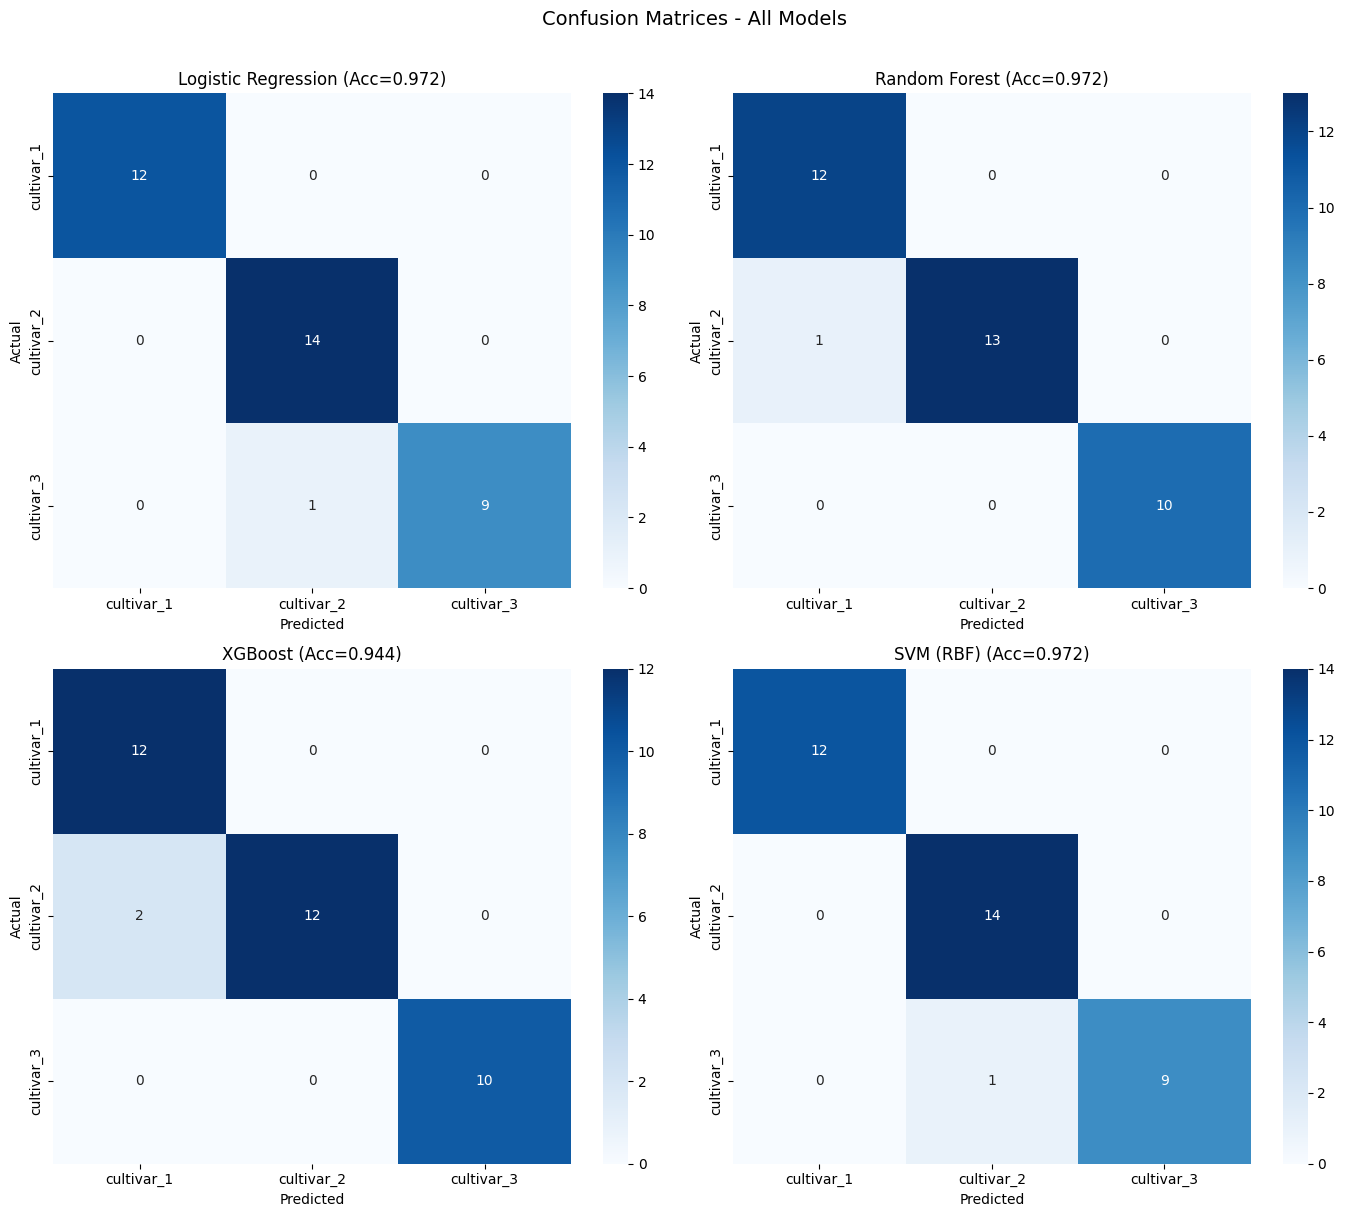

In [154]:
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrices for all 4 models
model_preds = {
    "Logistic Regression": lr_model.predict(X_test_scaled),
    "Random Forest": rf_model.predict(X_test),
    "XGBoost": xgb_model.predict(X_test),
    "SVM (RBF)": svc_model.predict(X_test_scaled),
}

class_names = ["cultivar_1", "cultivar_2", "cultivar_3"]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, (name, y_pred) in zip(axes.ravel(), model_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    acc = cm.diagonal().sum() / cm.sum()
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{name} (Acc={acc:.3f})")

plt.suptitle("Confusion Matrices - All Models", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Prediction & Evaluation

Predictions are made using the `predict()` method of the trained model.

Classification models are evaluated using metrics like:
- **Accuracy**: Proportion of correct predictions
- **Precision**: Proportion of positive identifications that were correct (multiclass uses averaging)
- **Recall**: Proportion of actual positives that were identified correctly
- **F1-score**: Harmonic mean of precision and recall

For multiclass problems (3+ classes), we use `average='weighted'` to combine per-class scores weighted by class support.

In [155]:
# TODO: Make predictions with each model and evaluate
# model_dictionary = {
#     "LogisticRegression": lr_model,
#     "RandomForest": rf_model,
#     "XGBoost": xgb_model,
#     "SVC": svc_model,
#     "DecisionTree": dt_model
# }
#
# For each model:
# - Make predictions on the test set (use scaled features for LR and SVC).
# - Calculate evaluation metrics with average='weighted': accuracy, precision, recall, F1.
# - Print the results in a formatted way.
# - Store the results in a dictionary for later comparison:
#   results = {
#       "LogisticRegression": {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1},
#       ...
#   }

In [156]:
# Evaluate all models (Decision Tree excluded — Random Forest covers it better)
models = {
    "LogisticRegression": (lr_model, X_test_scaled),
    "RandomForest": (rf_model, X_test),
    "XGBoost": (xgb_model, X_test),
    "SVC": (svc_model, X_test_scaled),
}

results = {}
for name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="macro"),
        "Recall": recall_score(y_test, y_pred, average="macro"),
        "F1_Macro": f1_score(y_test, y_pred, average="macro"),
    }

# Display results
results_df = pd.DataFrame(results).T.sort_values("F1_Macro", ascending=False)
print("=== Model Comparison (Test Set) ===")
print(results_df.round(4))
print(f"\nBest model by F1 Macro: {results_df.index[0]} ({results_df['F1_Macro'].iloc[0]:.4f})")

=== Model Comparison (Test Set) ===
                    Accuracy  Precision  Recall  F1_Macro
RandomForest          0.9722     0.9744  0.9762    0.9743
LogisticRegression    0.9722     0.9778  0.9667    0.9710
SVC                   0.9722     0.9778  0.9667    0.9710
XGBoost               0.9444     0.9524  0.9524    0.9487

Best model by F1 Macro: RandomForest (0.9743)


In [157]:
# TODO: Compare the performance of the models
# Create a DataFrame from the results dictionary:
# results_df = pd.DataFrame(results).T
# Use seaborn or matplotlib to create a bar plot comparing metrics across models.
#
# import seaborn as sns
# import matplotlib.pyplot as plt

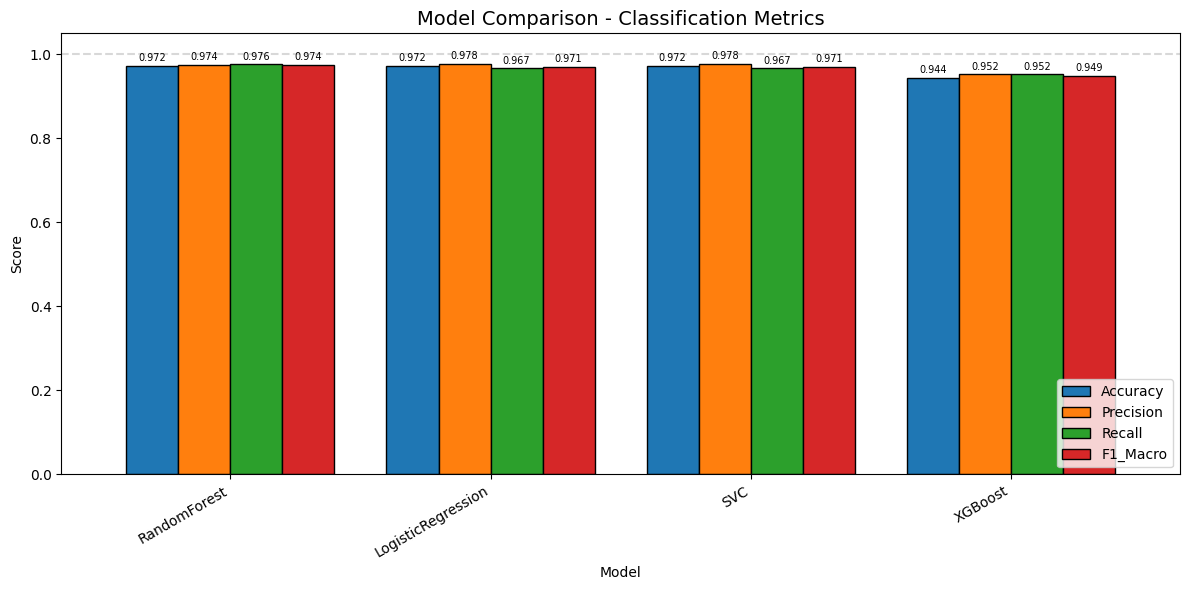

In [158]:
# Visual comparison of model performance
fig, ax = plt.subplots(figsize=(12, 6))
results_df.plot(kind="bar", ax=ax, width=0.8, edgecolor="black")
ax.set_title("Model Comparison - Classification Metrics", fontsize=14)
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.3)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=7, padding=2)

plt.tight_layout()
plt.show()

In [159]:
# TODO: Plot feature importance for tree-based models
# Importances are in rf_model.feature_importances_ and xgb_model.feature_importances_.
# They correspond to the columns in X_train.
# Use sns.barplot(x="importance", y="feature", data=top_features)
# to plot the top features for Random Forest and XGBoost.

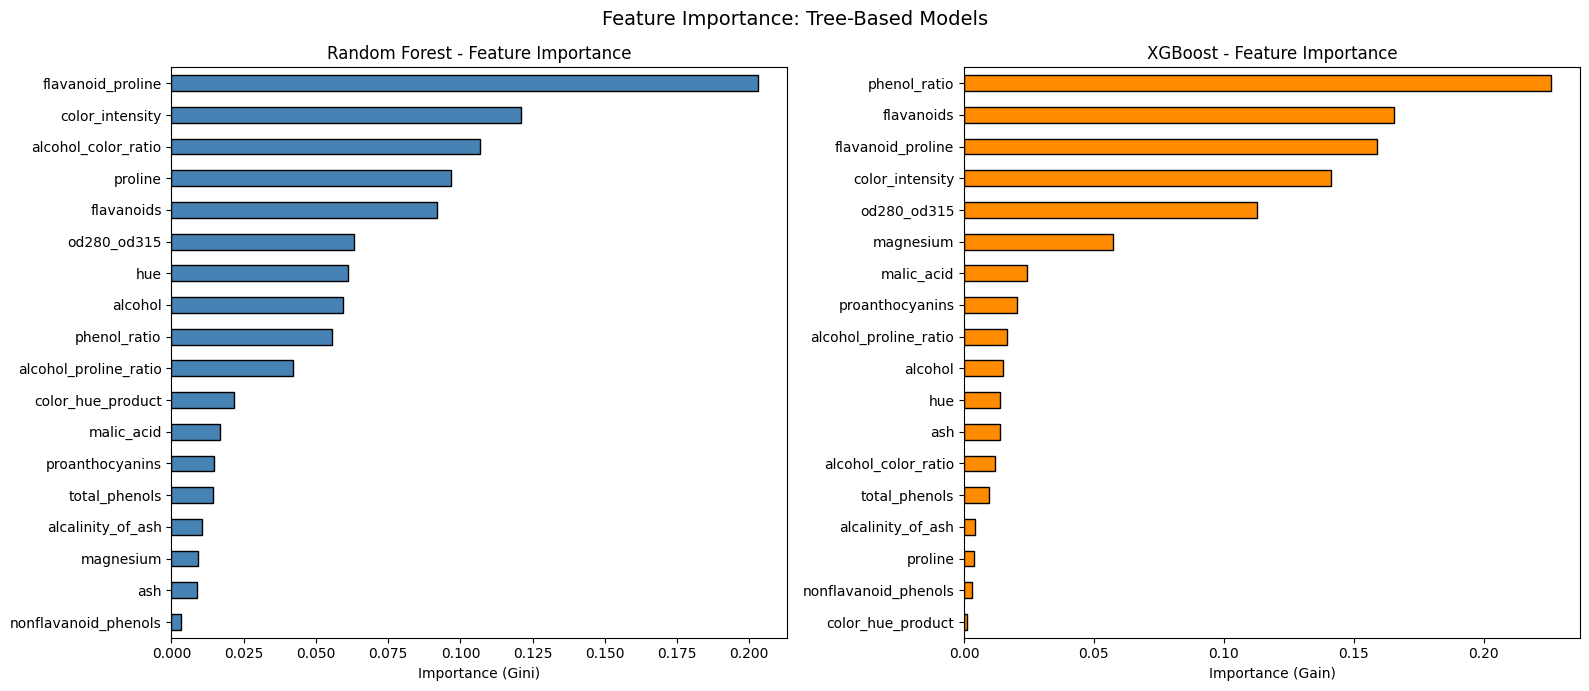

Top 5 features (Random Forest): ['flavanoid_proline', 'color_intensity', 'alcohol_color_ratio', 'proline', 'flavanoids']
Top 5 features (XGBoost):       ['phenol_ratio', 'flavanoids', 'flavanoid_proline', 'color_intensity', 'od280_od315']


In [160]:
# Feature importance comparison: Random Forest vs XGBoost
feature_names = X_train.columns.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Random Forest importances
rf_importance = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values()
rf_importance.plot(kind="barh", ax=ax1, color="steelblue", edgecolor="black")
ax1.set_title("Random Forest - Feature Importance")
ax1.set_xlabel("Importance (Gini)")

# XGBoost importances
xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values()
xgb_importance.plot(kind="barh", ax=ax2, color="darkorange", edgecolor="black")
ax2.set_title("XGBoost - Feature Importance")
ax2.set_xlabel("Importance (Gain)")

plt.suptitle("Feature Importance: Tree-Based Models", fontsize=14)
plt.tight_layout()
plt.show()

# Top 5 features for each model
print("Top 5 features (Random Forest):", rf_importance.sort_values(ascending=False).head(5).index.tolist())
print("Top 5 features (XGBoost):      ", xgb_importance.sort_values(ascending=False).head(5).index.tolist())

## Model Interpretability with SHAP

SHAP (SHapley Additive exPlanations) is a game-theoretic approach to explain the output of machine learning models. It provides consistent and locally accurate feature importance values by computing Shapley values from cooperative game theory.

Unlike traditional feature importance (which tells you which features matter globally), SHAP explains individual predictions — showing how each feature contributed to pushing a prediction away from the average.

### SHAP vs Traditional Feature Importance

While the bar charts above show global feature importance (average reduction in impurity across all trees), SHAP values provide:

- **Local explanations**: How each feature affects individual predictions
- **Consistency**: If a model changes so a feature matters more, its SHAP value never decreases
- **Directionality**: SHAP shows whether a feature pushes predictions up or down from the average

In [161]:
# TODO: Compute SHAP values for the Random Forest model
# Use shap.TreeExplainer(rf_model) to create an explainer.

In [162]:
import shap
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

sv = shap_values[1] if isinstance(shap_values, list) else shap_values[:,:,0]
print(f"SHAP values shape: {sv.shape}")

SHAP values shape: (36, 18)


In [163]:
# TODO: Create a SHAP summary plot
# Use shap.summary_plot() with the SHAP values and feature names.

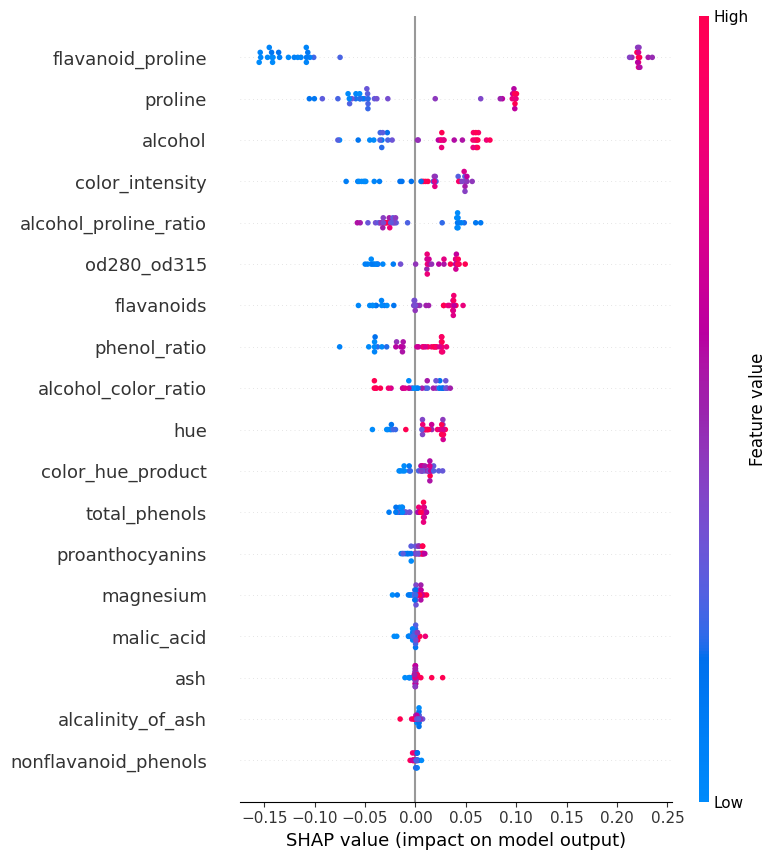

In [164]:
# SHAP summary plot (beeswarm) for class 0 (cultivar_1)
shap.summary_plot(sv, X_test, feature_names=feature_names, show=True)

In [165]:
# TODO: Create a SHAP dependence plot
# Choose a feature and use shap.dependence_plot() to show how it affects predictions.

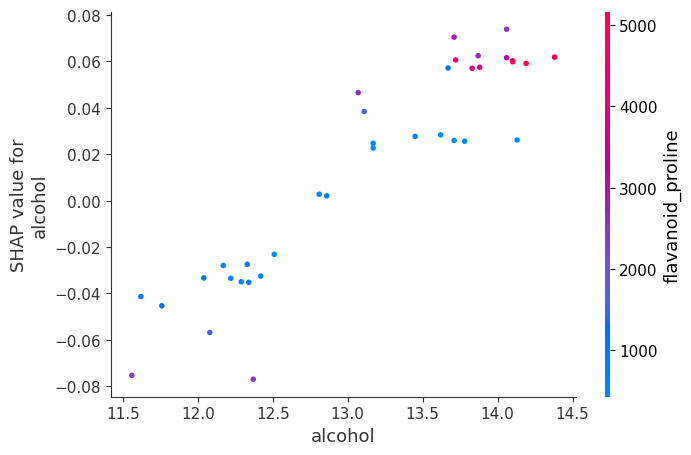

In [166]:
# SHAP dependence plot for the most important feature
shap.dependence_plot("alcohol", sv, X_test, feature_names=feature_names, show=True)

In [167]:
# TODO: Create a SHAP waterfall plot for one predicted class
# Pick a sample from X_test and use shap.plots.waterfall() to visualize feature contributions.


Sample 0: predicted class 0, actual class 0


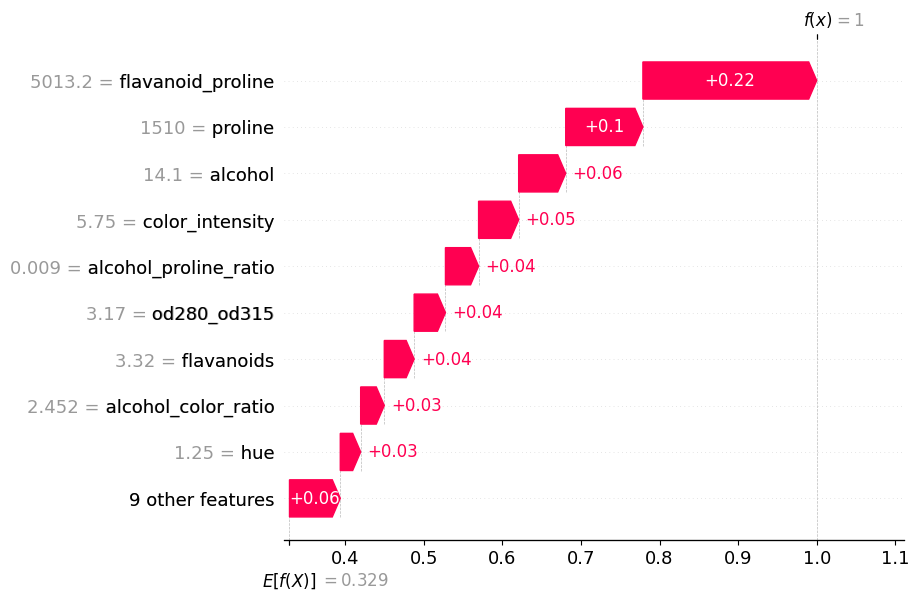

In [168]:
y_pred_test = rf_model.predict(X_test)
sample_idx = np.where(y_pred_test == 0)[0][0]
print(f"Sample {sample_idx}: predicted class 0, actual class {y_test.iloc[sample_idx]}")
shap.plots.waterfall(explainer(X_test)[:, :, 0][sample_idx])


In [169]:
# TODO: Create a SHAP waterfall plot for a different class
# Find a sample predicted as a different class and visualize that prediction.
#
# idx = np.where(y_pred == 1)[0][0]
# shap.plots.waterfall(explainer(X_test)[:,:,1][idx])

Sample 4: predicted class 1, actual class 1


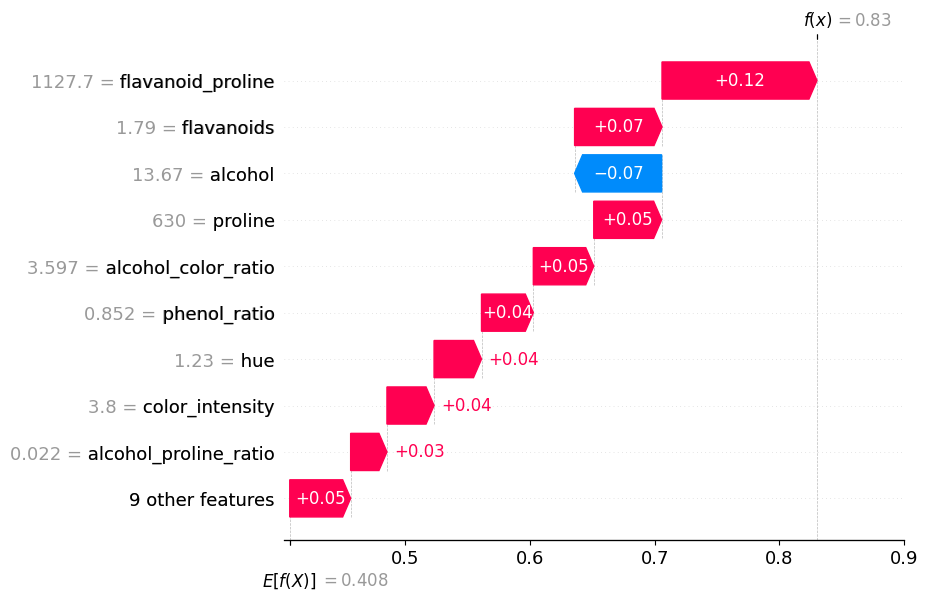

In [170]:
idx_class1 = np.where(y_pred_test == 1)[0][0]
print(f"Sample {idx_class1}: predicted class 1, actual class {y_test.iloc[idx_class1]}")
shap.plots.waterfall(explainer(X_test)[:, :, 1][idx_class1])
